<table style="width:100%">
  <tr>
    <td valign="top"><img src="../data/img/FER_logo_2.png" width=300 height=80 align="left"></td>
    <td valign="top"><img src="../data/img/LARES_2_transparent.png" width=250 height=80 align="right"></td>
  </tr>
 </table>

# Ensemble learning

![](../data/img/orchestra.jpg)

Dataset from: https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data

### Import modules

In [1]:
# import packages for data processing and plotting
#import warnings
#warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn import preprocessing
from scipy import stats
import pickle
import seaborn as sns
sns.set_theme()
import matplotlib.pyplot as plt

np.random.seed(123)

#%matplotlib inline

### Auxilary functions

In [2]:
# helper functions

def add_fit_to_histplot(a, fit=stats.norm, ax=None):
    '''
    Auxiliary function to plot PDF of equivalent normal distribution,
    since sns.distplot is deprecated.
    '''
    if ax is None:
        ax = plt.gca()

    # compute bandwidth
    bw = len(a)**(-1/5) * a.std(ddof=1)
    # initialize PDF support
    x = np.linspace(a.min()-bw*3, a.max()+bw*3, 200)
    # compute PDF parameters
    params = fit.fit(a)
    # compute PDF values
    y = fit.pdf(x, *params)
    # plot the fitted continuous distribution
    ax.plot(x, y, color='#282828')
    return ax

def transform_feat(feat, source, sink, transform):
    '''
    Transforms a column in source and places it in sink. 
    Prints dataframe with analysis, before and after.
    Plots 2 KDE plots, before and after.
    '''
    
    # apply transformation
    sink[feat] = source[feat].apply(transform)
    
    # make analysis
    temp1 = source[feat].describe()
    temp1['skew'] = source[feat].skew()
    temp1['kurt'] = source[feat].kurt()
    temp2 = sink[feat].describe()
    temp2['skew'] = sink[feat].skew()
    temp2['kurt'] = sink[feat].kurt()
    print(pd.DataFrame([temp1, temp2], index=['Before transform', 'After transform']).T)
    
    # plot histogram+KDE
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=[14, 4])
    ax1 = sns.histplot(source[feat], stat='density', kde=True, ax=ax1)
    ax1 = add_fit_to_histplot(source[feat], fit=stats.norm, ax=ax1)
    ax1.legend(['Actual distribution', 'Normal distribution'])
    ax1.set_title('Histogram and KDE, before transform')
    ax2 = sns.histplot(sink[feat], stat='density', kde=True, ax=ax2)
    ax2 = add_fit_to_histplot(sink[feat], fit=stats.norm, ax=ax2)
    ax2.legend(['Actual distribution', 'Normal distribution'])
    ax2.set_title('Histogram and KDE, after transform')

def compare_cat(feat, df, figsize, order=None):
    '''
    Compares a categorical feature to the label in a boxplot.
    '''
    fig, ax = plt.subplots(figsize=figsize)
    ax = sns.boxplot(x=feat, y="SalePrice", hue=feat, legend=False, data=df, 
                     order=order, palette="muted", flierprops={"marker": "x"})
    if len(ax.get_xticks()) > 15:
        ax.xaxis.set_tick_params(rotation=45)
    else:
        ax.xaxis.set_tick_params(rotation=0)
    ax.set_title("Box plot - comperison with label")
    
def compare_num(feat, source, sink):
    '''
    Compares a numerical feature to the label in a scatterplot.
    '''
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=[14, 4])
    ax1 = sns.scatterplot(x=feat, y="SalePrice", data=source, ax=ax1, alpha=0.5)
    ax1.set_title("Scatter plot - before transformations")
    ax2 = sns.scatterplot(x=feat, y="SalePrice", data=sink, ax=ax2, alpha=0.5)
    ax2.set_title("Scatter plot - after transformations");

## 0. (Pre)process data

In [3]:
# load the dataset
filepath = '../data/housing_prices/housing.csv'
df_raw = pd.read_csv(filepath, index_col='Id')

# take a look at it
print("Shape of dataset:", df_raw.shape)
df_raw.sample(5)

Shape of dataset: (1460, 80)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
148,60,RL,NaN,9505,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,222500
677,70,RM,60.0,9600,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,87000
1305,160,RM,32.0,3363,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,130000
1373,60,RL,75.0,9750,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,274300
1428,50,RL,60.0,10930,Pave,Grvl,Reg,Bnk,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2008,WD,Normal,140000


In [4]:
# choose columns to use
cols = ['MSSubClass', 'LotArea', 'Neighborhood', 'OverallQual', 'YearBuilt', 'PoolArea', 'ExterQual',
        'BsmtUnfSF', 'TotalBsmtSF', 'GrLivArea', 'KitchenQual', 'GarageArea', 'MoSold', 'SalePrice']
df_raw = df_raw[cols]

# check the dataset
print('Shape of dataset:', df_raw.shape)
print('Data types:')
print(df_raw.dtypes)
df_raw.sample(5)

Shape of dataset: (1460, 14)
Data types:
MSSubClass       int64
LotArea          int64
Neighborhood    object
OverallQual      int64
YearBuilt        int64
PoolArea         int64
ExterQual       object
BsmtUnfSF        int64
TotalBsmtSF      int64
GrLivArea        int64
KitchenQual     object
GarageArea       int64
MoSold           int64
SalePrice        int64
dtype: object


,MSSubClass,LotArea,Neighborhood,OverallQual,YearBuilt,PoolArea,ExterQual,BsmtUnfSF,TotalBsmtSF,GrLivArea,KitchenQual,GarageArea,MoSold,SalePrice
Id,,,,,,,,,,,,,,
275,20,8314,Mitchel,5,1982,0,TA,270,816,816,TA,264,6,124500
1046,20,13680,Edwards,3,1955,0,TA,0,0,1733,TA,452,6,139600
1453,180,3675,Edwards,5,2005,0,TA,0,547,1072,TA,525,5,145000
906,20,9920,NAmes,5,1954,0,TA,412,1056,1063,TA,280,2,128000
836,20,9600,Sawyer,4,1950,0,TA,625,1067,1067,Gd,436,2,128000


In [5]:
# check for missing values
print('Number of NaN values per columns:')
print(df_raw.isna().sum())

Number of NaN values per columns:
MSSubClass      0
LotArea         0
Neighborhood    0
OverallQual     0
YearBuilt       0
PoolArea        0
ExterQual       0
BsmtUnfSF       0
TotalBsmtSF     0
GrLivArea       0
KitchenQual     0
GarageArea      0
MoSold          0
SalePrice       0
dtype: int64


       Before transform  After transform
count       1460.000000      1460.000000
mean      180921.195890        12.024057
std        79442.502883         0.399449
min        34900.000000        10.460271
25%       129975.000000        11.775105
50%       163000.000000        12.001512
75%       214000.000000        12.273736
max       755000.000000        13.534474
skew           1.882876         0.121347
kurt           6.536282         0.809519


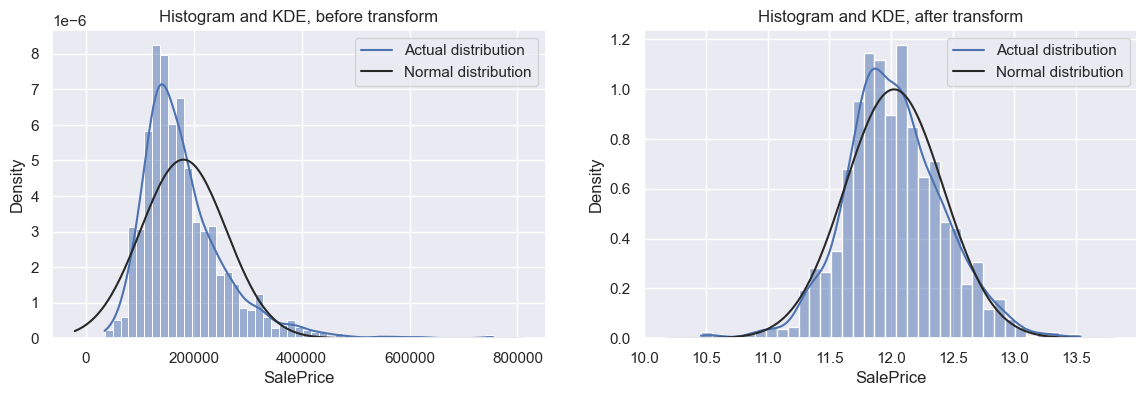

In [7]:
# SalePrice: label, target values
# -> numerical -- regression problem
# -> log transformation to be closer to normal distribution
feat = 'SalePrice'
transform_feat(feat, df_raw, df_proc, np.log1p)

Original data type of MSSubClass is int64
New data type of MSSubClass is object


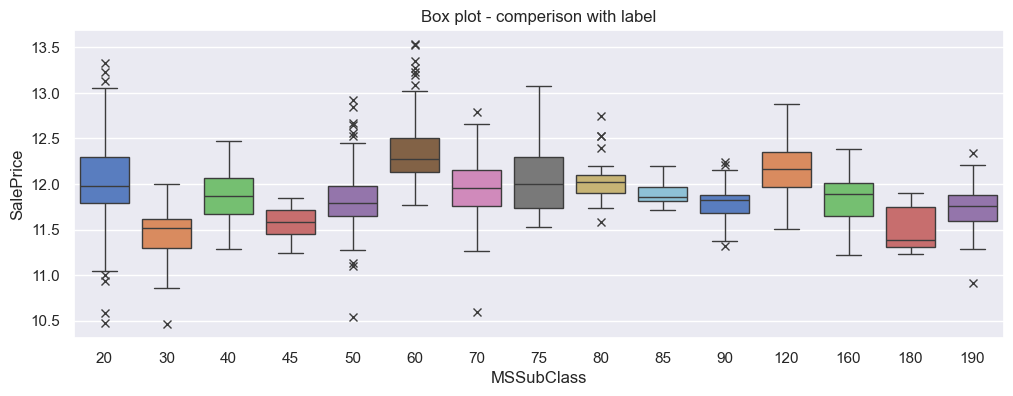

In [8]:
# MSSubClass: Identifies the type of dwelling involved in the sale.
# -> categorical feature
# -> originally int64, but it's type should be object
# -> it will be one-hot encoded later
feat = 'MSSubClass'
df_proc[feat] = df_proc[feat].astype('object')
print('Original data type of', feat, 'is', df_raw[feat].dtype)
print('New data type of', feat, 'is', df_proc[feat].dtype)
compare_cat(feat, df_proc, (12,4))

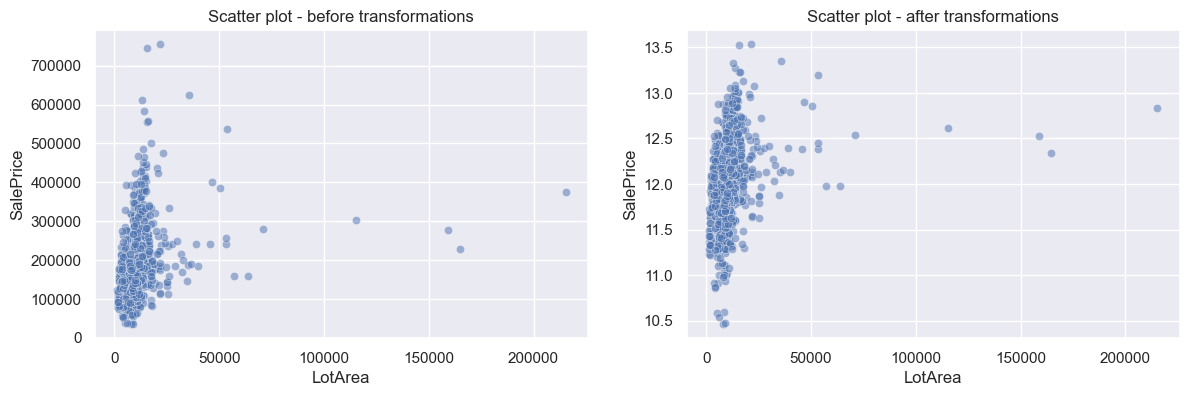

In [9]:
# LotArea: Lot size in square feet
# -> numerical feature
# -> no transformations
feat = 'LotArea'
compare_num(feat, df_raw, df_proc)

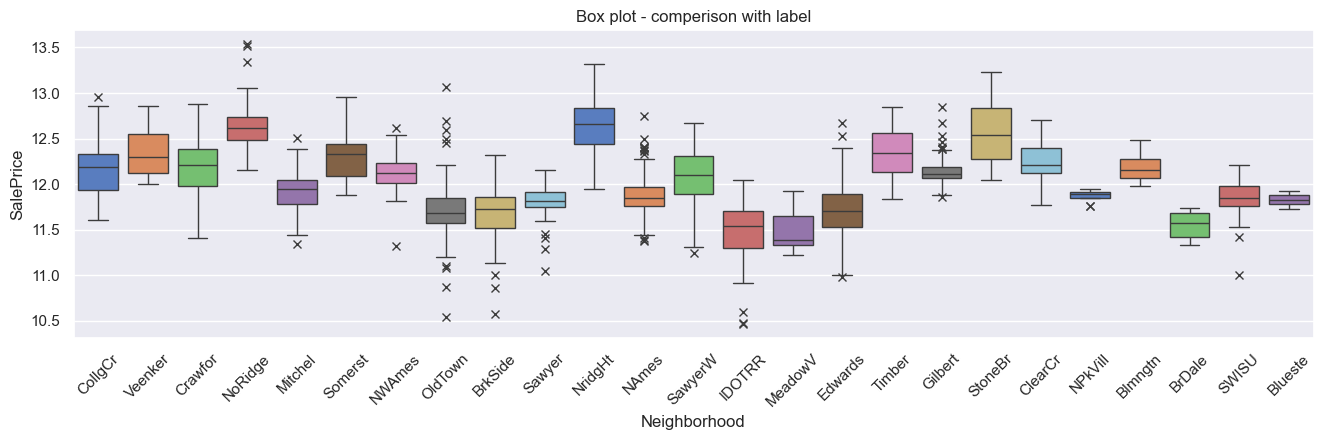

In [10]:
# Neighborhood: Physical locations within Ames city limits
# -> categorical feature
# -> no need for changing
# -> it will be one-hot encoded later
feat = 'Neighborhood'
compare_cat(feat, df_proc, (16,4))

In [6]:
# make another dataframe to save the "raw" dataframe
df_proc = df_raw.copy()

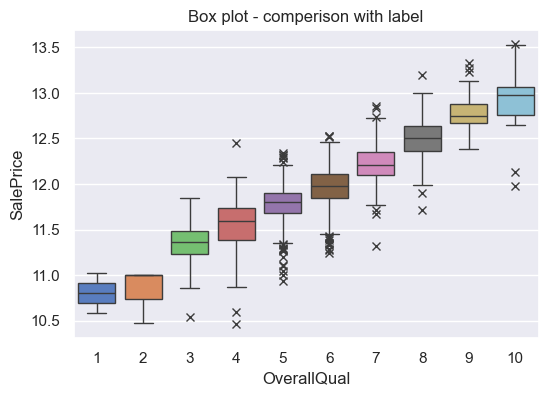

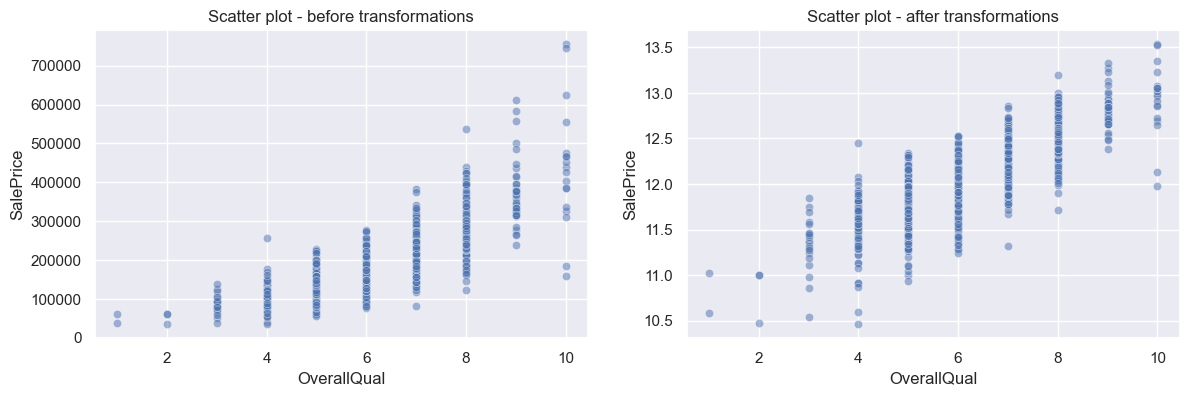

In [11]:
# OverallQual: Rates the overall material and finish of the house
# -> seems categorical, but it can be treated as numerical feature
# -> no need for processing
feat = 'OverallQual'
compare_cat(feat, df_proc, (6,4))
compare_num(feat, df_raw, df_proc)

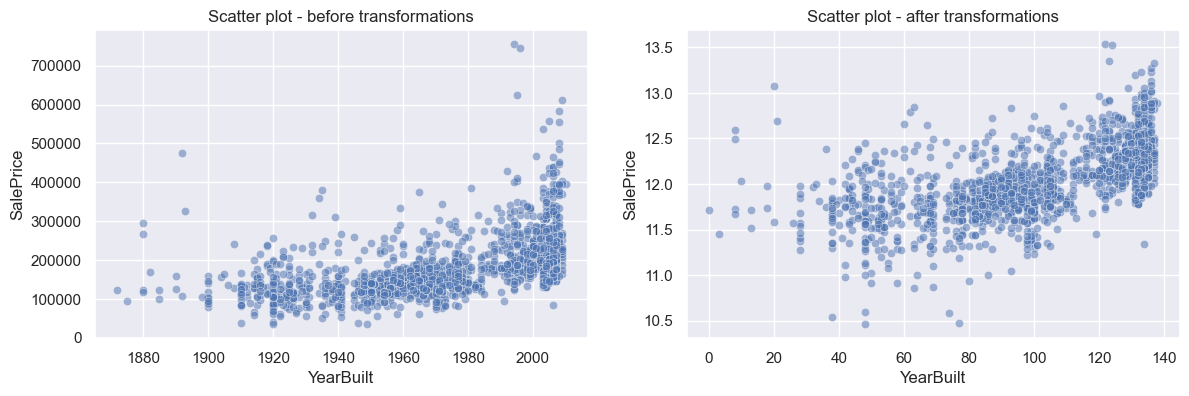

In [12]:
# YearBuilt: Original construction date
# -> numerical feature
# -> subtract the minimal value so that values start with 0
feat = 'YearBuilt'
df_proc[feat] = df_raw[feat] - df_raw[feat].min()
compare_num(feat, df_raw, df_proc)

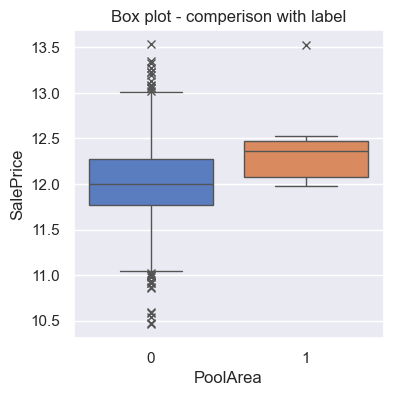

In [13]:
# PoolArea: Pool area in square feet
# -> originally numerical feature
# -> since not many houses have a pool, this can be turned into categorical feature:
#    does the house have a pool or not (binary feature)
# -> changed into integer (as one-hot encoding)
feat = 'PoolArea'
df_proc[feat] = (df_raw[feat] > 0).astype(int)
compare_cat(feat, df_proc, (4,4))

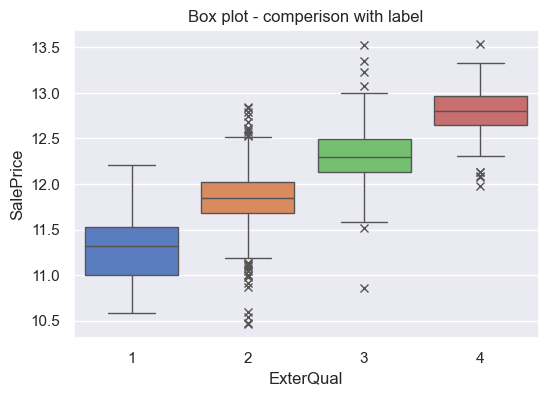

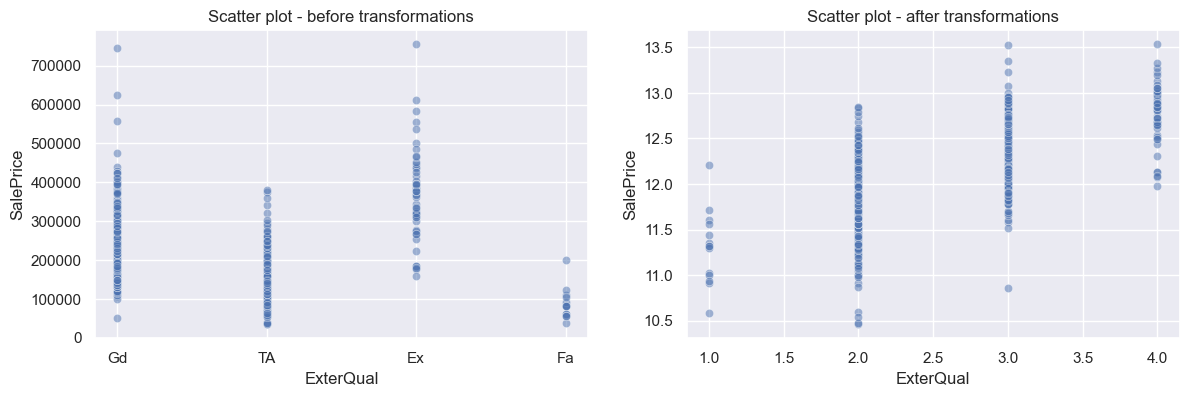

In [14]:
# ExterQual: Evaluates the quality of the material on the exterior
# -> seems categorical, but it can be treated as numerical feature
# -> string marks converted into integers
feat = 'ExterQual'
marks = {'Fa': '1', 'TA': '2', 'Gd': '3', 'Ex': '4'}
df_proc[feat] = df_raw[feat].replace(marks).astype(np.int64)
compare_cat(feat, df_proc, (6,4))
compare_num(feat, df_raw, df_proc)

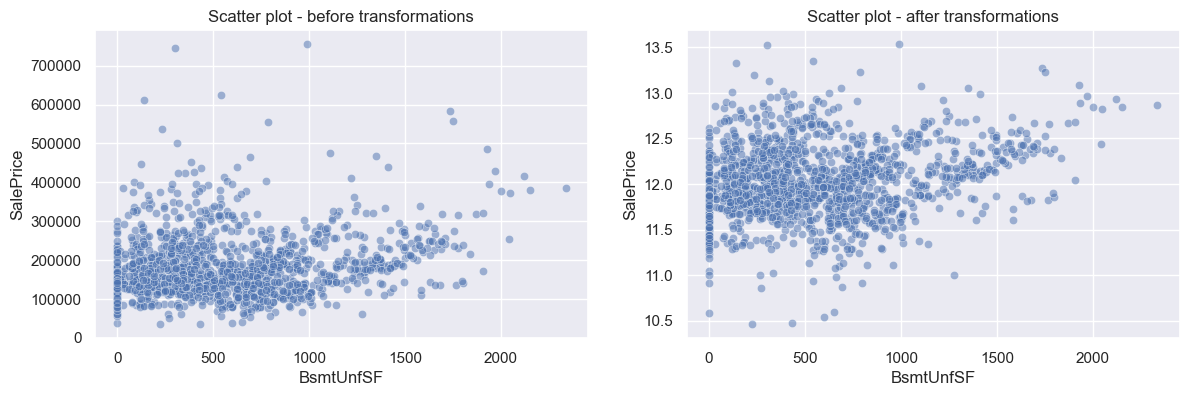

In [15]:
# BsmtUnfSF: Unfinished square feet of basement area
# -> numerical feature
# -> no need for transformation
feat = 'BsmtUnfSF'
compare_num(feat, df_raw, df_proc)

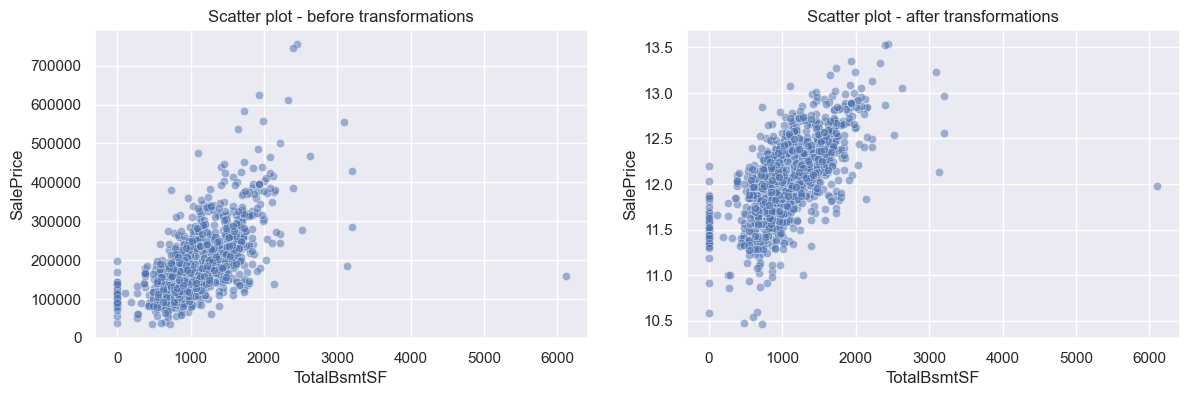

In [16]:
# TotalBsmtSF: Total square feet of basement area
# -> numerical feature
# -> no transformation
feat = 'TotalBsmtSF'
compare_num(feat, df_raw, df_proc)

       Before transform  After transform
count       1460.000000      1460.000000
mean        1515.463699         7.268512
std          525.480383         0.333303
min          334.000000         5.814131
25%         1129.500000         7.030415
50%         1464.000000         7.289611
75%         1776.750000         7.483104
max         5642.000000         8.638171
skew           1.366560        -0.006140
kurt           4.895121         0.281988


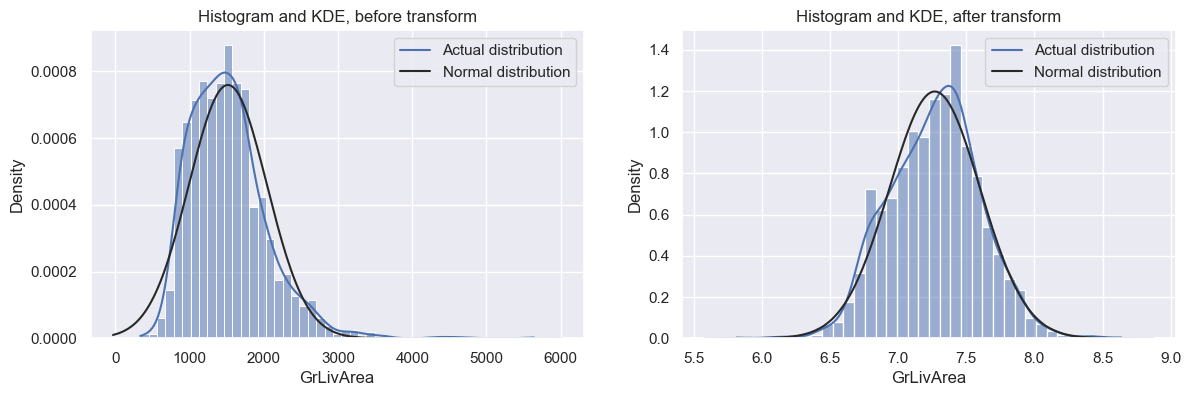

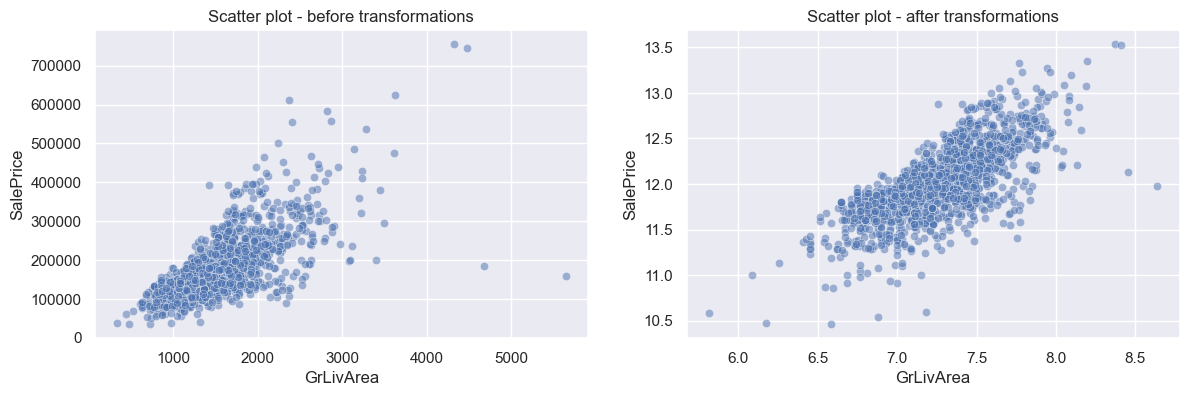

In [17]:
# GrLivArea: Above grade (ground) living area square feet
# -> numerical feature
# -> log transformation
feat = 'GrLivArea'
transform_feat(feat, df_raw, df_proc, np.log1p)
compare_num(feat, df_raw, df_proc)

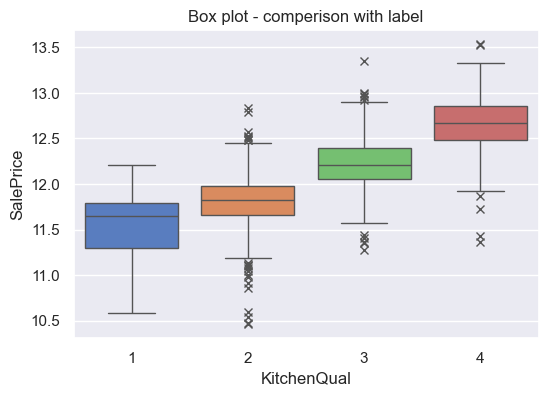

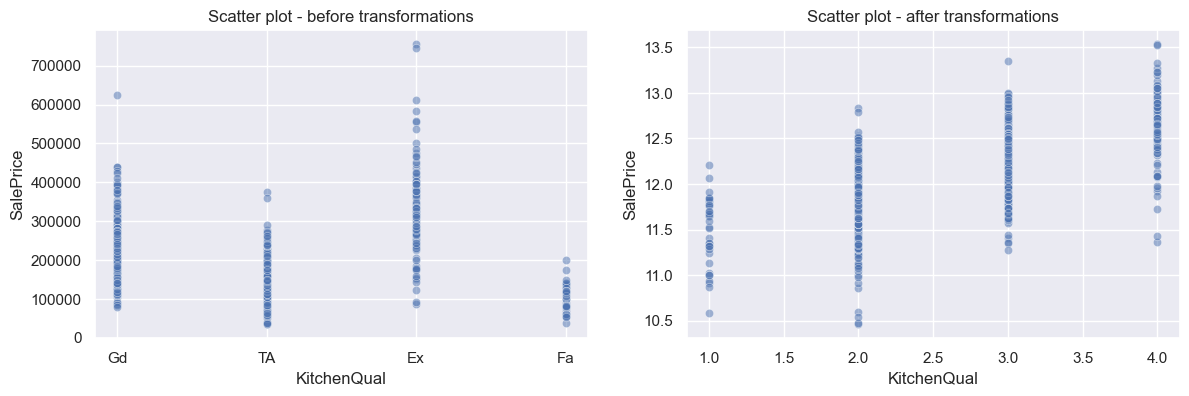

In [18]:
# KitchenQual: Kitchen quality
# -> seems categorical, but it can be treated as numerical feature
feat = 'KitchenQual'
marks = {'Fa': '1', 'TA': '2', 'Gd': '3', 'Ex': '4'}
df_proc[feat] = df_raw[feat].replace(marks).astype(np.int64)
compare_cat(feat, df_proc, (6,4))
compare_num(feat, df_raw, df_proc)

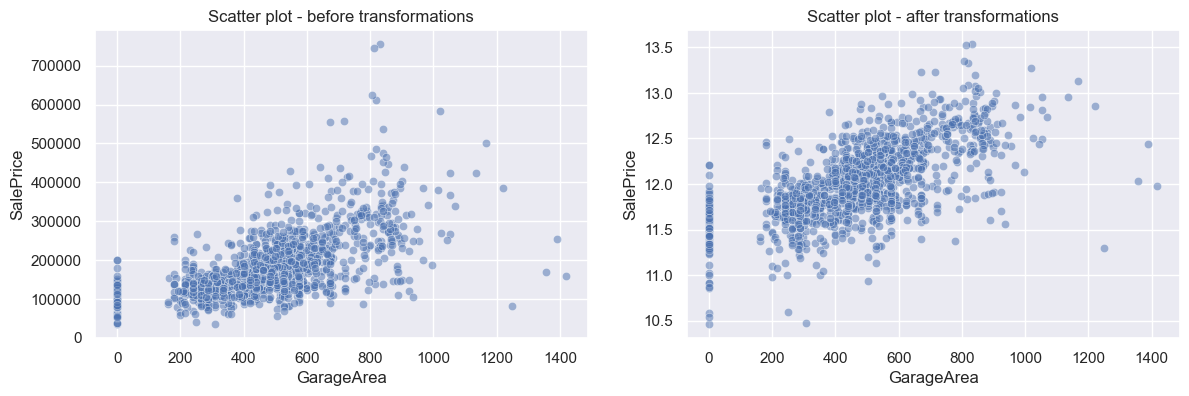

In [19]:
# GarageArea: Size of garage in square feet
# -> numerical feature
feat = 'GarageArea'
compare_num(feat, df_raw, df_proc)

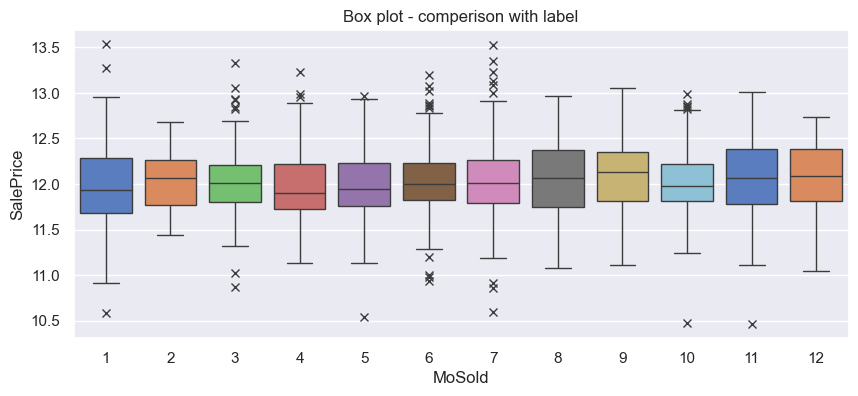

In [20]:
# MoSold: Month Sold (MM)
# -> categorical feature
# -> convert int to object
feat = 'MoSold'
df_proc[feat] = df_raw[feat].astype('object')
compare_cat(feat, df_proc, (10,4))

In [21]:
# one-hot encoding of categorical features
cat_cols = ['MSSubClass', 'Neighborhood', 'PoolArea', 'MoSold']
df_cat_1hot = pd.get_dummies(df_proc[cat_cols], columns=cat_cols, drop_first=True)

In [22]:
# scaling numerical features
num_cols = ['LotArea', 'OverallQual', 'YearBuilt', 'ExterQual', 'BsmtUnfSF', 
            'TotalBsmtSF', 'GrLivArea', 'KitchenQual', 'GarageArea']
scaler = preprocessing.RobustScaler()
scaler.fit(df_proc[num_cols])
df_num_scaled = pd.DataFrame(scaler.transform(df_proc[num_cols]), columns=num_cols, index=df_proc.index)

In [24]:
# merging numerical and categorical features, and label
df_full = pd.concat([df_num_scaled, df_cat_1hot, df_proc['SalePrice'].to_frame()], axis=1)

In [25]:
# divide data into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df_full.drop(columns='SalePrice'), df_full['SalePrice'], test_size=0.2, random_state=123
)

In [23]:
# save the scaler to disk
filename = '../models/ensemble_scaler.pkl'
pickle.dump(scaler, open(filename, 'wb'))

# load the scaler from disk
# scaler = pickle.load(open(filename, 'rb'))
# result = scaler.transform(df_proc[num_cols])

## Part 1: Simple ensemble methods

1) Averaging
2) Weighted averaging
3) Blending
4) Stacking

### Learning base models
- linear regression
- lasso
- ridge
- SVM

In [26]:
# import stuff
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV

#### Linear Regression (LR) model
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html   
`sklearn.linear_model.`**`LinearRegression`**`(*, fit_intercept=True, copy_X=True, n_jobs=None, positive=False)`

In [27]:
# 1. Create/build model
LR = LinearRegression()
# 2. Fit model
LR.fit(X_train, y_train)
# 3. Evaluate model
y_LR = LR.predict(X_test)
error_LR = root_mean_squared_error(y_test, y_LR)
print('Linear regression RMSE: {:6f}'.format(error_LR))

Linear regression RMSE: 0.130713


In [28]:
# save the model to disk
filename = '../models/ensemble_LR.pkl'
pickle.dump(LR, open(filename, 'wb'))
 
# load the model from disk
# LR = pickle.load(open(filename, 'rb'))
# result = LR.predict(X_test)

#### Lasso regression model
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html   
`sklearn.linear_model.`**`Lasso`**`(alpha=1.0, *, fit_intercept=True, precompute=False, copy_X=True, max_iter=1000, tol=0.0001, warm_start=False, positive=False, random_state=None, selection='cyclic')`

In [29]:
# find the best hyperparameter
estimator = Lasso()
param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
}
gscv = GridSearchCV(estimator, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
gscv.fit(X_train, y_train)
print('The best hyperparameter for Lasso is: {}'.format(gscv.best_params_))

The best hyperparameter for Lasso is: {'alpha': 0.001}


In [30]:
# 1. Create/build model
lasso = Lasso(alpha=0.001)
# 2. Fit model
lasso.fit(X_train, y_train)
# 3. Evaluate model
y_lasso = lasso.predict(X_test)
error_lasso = root_mean_squared_error(y_test, y_lasso)
print('Lasso regression RMSE: {:6f}'.format(error_lasso))

Lasso regression RMSE: 0.127296


In [31]:
# save the model to disk
filename = '../models/ensemble_lasso.pkl'
pickle.dump(lasso, open(filename, 'wb'))
 
# load the model from disk
# lasso = pickle.load(open(filename, 'rb'))
# result = lasso.predict(X_test)

#### Ridge regression model
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html    
`sklearn.linear_model.`**`Ridge`**`(alpha=1.0, *, fit_intercept=True, copy_X=True, max_iter=None, tol=0.0001, solver='auto', positive=False, random_state=None)`

In [32]:
# find the best hyperparameter
estimator = Ridge()
param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
}
gscv = GridSearchCV(estimator, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
gscv.fit(X_train, y_train)
print('The best hyperparameter for Ridge is: {}'.format(gscv.best_params_))

The best hyperparameter for Ridge is: {'alpha': 10}


In [33]:
# 1. Create/build model
ridge = Ridge(alpha=10)
# 2. Fit model
ridge.fit(X_train, y_train)
# 3. Evaluate model
y_ridge = ridge.predict(X_test)
error_ridge = root_mean_squared_error(y_test, y_ridge)
print('Ridge regression RMSE: {:6f}'.format(error_ridge))

Ridge regression RMSE: 0.127815


In [34]:
# save the model to disk
filename = '../models/ensemble_ridge.pkl'
pickle.dump(ridge, open(filename, 'wb'))
 
# load the model from disk
# ridge = pickle.load(open(filename, 'rb'))
# result = ridge.predict(X_test)

#### Suport Vector Machine (SVM) model
https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html   
`sklearn.svm.`**`SVR`**`(*, kernel='rbf', degree=3, gamma='scale', coef0=0.0, tol=0.001, C=1.0, epsilon=0.1, shrinking=True, cache_size=200, verbose=False, max_iter=-1)`

In [35]:
%%time
# find the best hyperparameters
estimator = SVR(cache_size=2000)
param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.1, 0.5, 1, 5, 10],
        'epsilon': [0.01, 0.05, 0.1, 0.5, 1]
    },
    {
        'kernel': ['poly'],
        'degree': [2, 3, 4],
        'gamma': ['scale', 'auto'],
        'C': [0.1, 0.5, 1, 5, 10],
        'epsilon': [0.01, 0.05, 0.1, 0.5, 1]
    }, 
    {
        'kernel': ['rbf'],
        'gamma': ['scale', 'auto'],
        'C': [0.1, 0.5, 1, 5, 10],
        'epsilon': [0.01, 0.05, 0.1, 0.5, 1]
    }, 
    {
        'kernel': ['sigmoid'],
        'gamma': ['scale', 'auto'],
        'C': [0.1, 0.5, 1, 5, 10],
        'epsilon': [0.01, 0.05, 0.1, 0.5, 1]
    }
]
gscv = GridSearchCV(estimator, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
gscv.fit(X_train, y_train)
print('The best hyperparameter for SVM is: {}'.format(gscv.best_params_))

The best hyperparameter for SVM is: {'C': 1, 'epsilon': 0.05, 'gamma': 'auto', 'kernel': 'rbf'}
CPU times: total: 3.66 s
Wall time: 43.4 s


In [36]:
# 1. Create/build model
SVM = SVR(C=1, epsilon=0.05, gamma='auto', kernel='rbf')
# 2. Fit model
SVM.fit(X_train, y_train)
# 3. Evaluate model
y_SVM = SVM.predict(X_test)
error_SVM = root_mean_squared_error(y_test, y_SVM)
print('SVM regression RMSE: {:6f}'.format(error_SVM))

SVM regression RMSE: 0.127403


In [37]:
# save the model to disk
filename = '../models/ensemble_SVM.pkl'
pickle.dump(SVM, open(filename, 'wb'))
 
# load the model from disk
# SVM = pickle.load(open(filename, 'rb'))
# result = SVM.predict(X_test)

### Averaging

In [38]:
# averaging with no weights
y_hat = (1*y_LR + 1*y_lasso + 1*y_ridge + 1*y_SVM) / 4
error_avg = root_mean_squared_error(y_test, y_hat)
print('Averaging RMSE: {:6f}'.format(error_avg))

Averaging RMSE: 0.125497


In [39]:
# weighted averaging - instinctively
y_hat = (1*y_LR + 3*y_lasso + 2*y_ridge + 4*y_SVM) / 10
error_avg = root_mean_squared_error(y_test, y_hat)
print('Averaging RMSE: {:6f}'.format(error_avg))

Averaging RMSE: 0.124518


In [40]:
# weighted averaging - with errors
y_hat = ((1/error_LR)*y_LR + (1/error_lasso)*y_lasso + (1/error_ridge)*y_ridge + (1/error_SVM)*y_SVM) / \
        ((1/error_LR) + (1/error_lasso) + (1/error_ridge) + (1/error_SVM))
error_avg = root_mean_squared_error(y_test, y_hat)
print('Averaging RMSE: {:6f}'.format(error_avg))

Averaging RMSE: 0.125475


### Blending

In [41]:
# prepare data
X_train_blend, X_val_blend, y_train_blend, y_val_blend = train_test_split(X_train, y_train, test_size=0.5, random_state=123)

**1. Train each model on train set**   
![blending 1.](../data/img/blend1_0.25.png)

In [42]:
# LR
LR_blend = LinearRegression().fit(X_train_blend, y_train_blend)

# Lasso
lasso_blend = Lasso(alpha=0.001).fit(X_train_blend, y_train_blend)

# Ridge
ridge_blend = Ridge(alpha=10).fit(X_train_blend, y_train_blend)

# SVM
SVM_blend = SVR(C=1, epsilon=0.05, gamma='auto', kernel='rbf').fit(X_train_blend, y_train_blend)

**2. Use trained models to generate training set for meta-model**   
![blending 2.](../data/img/blend2_0.25.png)

In [43]:
# generate predictions
y_LR_blend = LR_blend.predict(X_val_blend)
y_lasso_blend = lasso_blend.predict(X_val_blend)
y_ridge_blend = ridge_blend.predict(X_val_blend)
y_SVM_blend = SVM_blend.predict(X_val_blend)

In [44]:
# gather predictions into train set for the meta-model - numpy array
'''
X_train_meta = np.concatenate((
    y_LR_blend.reshape(-1, 1),
    y_lasso_blend.reshape(-1, 1),
    y_ridge_blend.reshape(-1, 1),
    y_SVM_blend.reshape(-1, 1)
), axis=1)
X_train_meta
'''

# gather predictions into train set for the meta-model - pandas dataframe
X_train_meta = pd.DataFrame({
    'y_LR_blend': y_LR_blend,
    'y_lasso_blend': y_lasso_blend,
    'y_ridge_blend': y_ridge_blend,
    'y_SVM_blend': y_SVM_blend
}, index=y_val_blend.index)
X_train_meta.head()

,y_LR_blend,y_lasso_blend,y_ridge_blend,y_SVM_blend
Id,,,,
1324,11.268649,11.230817,11.225607,11.230882
96,12.015310,12.002081,12.027998,12.037922
90,11.690022,11.636671,11.625167,11.696328
1133,11.907782,11.854795,11.873302,11.979714
782,12.089731,12.113322,12.106840,12.067163


**3. a) Use newly generated data to train meta-model**   
![blending 3.a](../data/img/blend3a_0.25.png)

In [45]:
# use Ridge with default hyperparameter (Singular Value Decomposition for numerical stability)
meta = Ridge(solver='svd').fit(X_train_meta, y_val_blend)

In [46]:
# save the model to disk
filename = '../models/ensemble_blend_meta.pkl'
pickle.dump(meta, open(filename, 'wb'))
 
# load the model from disk
# meta = pickle.load(open(filename, 'rb'))
# result = meta.predict(X_test)

**3. b) Train each model on the whole train+validation set**   
![blend 3.b](../data/img/blend3b_0.25.png)

In [47]:
# LR
LR_blend = LinearRegression().fit(X_train, y_train)

# Lasso
lasso_blend = Lasso(alpha=0.001).fit(X_train, y_train)

# Ridge
ridge_blend = Ridge(alpha=10).fit(X_train, y_train)

# SVM
SVM_blend = SVR(C=1, epsilon=0.05, gamma='auto', kernel='rbf').fit(X_train, y_train)

#### Evaluate the blending ensemble   
![evaluate blending](../data/img/blend4_0.25.png)

In [48]:
# use test set to make predictions with base models
y_LR = LR_blend.predict(X_test)
y_lasso = lasso_blend.predict(X_test)
y_ridge = ridge_blend.predict(X_test)
y_SVM = SVM_blend.predict(X_test)

In [49]:
# gather base predictions
X_test_meta = pd.DataFrame({
    'y_LR_blend': y_LR,
    'y_lasso_blend': y_lasso,
    'y_ridge_blend': y_ridge,
    'y_SVM_blend': y_SVM
}, index=y_test.index)

In [50]:
# make predictions
y_blend = meta.predict(X_test_meta)

# score of blending
error_blend = root_mean_squared_error(y_test, y_blend)
print('Blending RMSE: {:6f}'.format(error_blend))

Blending RMSE: 0.124068


### Stacking

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingRegressor.html   
`sklearn.ensemble.`**`StackingRegressor`**`(estimators, final_estimator=None, *, cv=None, n_jobs=None, passthrough=False, verbose=0)`

In [51]:
# import stacking regressor
from sklearn.ensemble import StackingRegressor

In [52]:
# make stacking ensemble
estimators = [
    ('LR', LinearRegression()),
    ('lasso', Lasso(alpha=0.001)),
    ('ridge', Ridge(alpha=10)),
    ('SVM', SVR(C=1, epsilon=0.05, gamma='auto', kernel='rbf'))
]
stacker = StackingRegressor(estimators, final_estimator=Ridge(solver='svd'), cv=4)

In [53]:
# fit and predict
stacker.fit(X_train, y_train)
y_stack = stacker.predict(X_test)

In [54]:
# score of stacking
error_stack = root_mean_squared_error(y_test, y_stack)
print('Stacking RMSE: {:6f}'.format(error_stack))

Stacking RMSE: 0.123609


In [55]:
# save the model to disk
filename = '../models/ensemble_stack.pkl'
pickle.dump(stacker, open(filename, 'wb'))
 
# load the model from disk
# stacker = pickle.load(open(filename, 'rb'))
# result = stacker.predict(X_test)

## Part 2: Bootstrap aggregating (bagging)   
![bagging](../data/img/bagging_0.25.png)

### Random Forests   

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html   
`sklearn.ensemble.`**`RandomForestRegressor`**`(n_estimators=100, *, criterion='squared_error', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=1.0, max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, ccp_alpha=0.0, max_samples=None)`

In [56]:
# import random forest
from sklearn.ensemble import RandomForestRegressor

**Default hyperparameters**

In [57]:
# Create model (random_state=123, n_jobs=-1)
RF_default = RandomForestRegressor(random_state=123, n_jobs=-1)

# Fit and predict
RF_default.fit(X_train, y_train)
y_RF_default = RF_default.predict(X_test)

# Evaluate model
error_RF_default = root_mean_squared_error(y_test, y_RF_default)
print('Default RF RMSE: {:6f}'.format(error_RF_default))

Default RF RMSE: 0.143546


In [58]:
# why is score so "bad"? -> check for overfitting
error_RF_default_train = root_mean_squared_error(y_train, RF_default.predict(X_train))
print('Train RMSE of default RF: {:6f}'.format(error_RF_default_train))

Train RMSE of default RF: 0.059647


**Tuned hyperparameters**

In [59]:
%%time
# tune hyperparameters using GridSearchCV - tree defining hyperparameters
estimator = RandomForestRegressor(random_state=123, n_jobs=-1)
param_grid = {
    'max_depth': [5, 10],
    'min_samples_split': [2, 4, 8],
    'min_samples_leaf': [1, 2, 4]
}
gscv1 = GridSearchCV(estimator, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, refit=True)
gscv1.fit(X_train, y_train)
print('The best hyperparameters for RF are: {}'.format(gscv1.best_params_))

The best hyperparameters for RF are: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 4}
CPU times: total: 1.55 s
Wall time: 11.5 s


In [60]:
%%time
# tune hyperparameters using GridSearchCV - bagging defining hyperparameters
estimator = RandomForestRegressor(random_state=234, n_jobs=-1, **gscv1.best_params_)
param_grid = {
    'max_samples': [0.5, 0.6, 0.7, 0.8, 0.9],
    'max_features': [0.5, 0.6, 0.7, 0.8, 0.9]
}
gscv2 = GridSearchCV(estimator, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, refit=True)
gscv2.fit(X_train, y_train)
print('The best hyperparameters for RF are: {}'.format(gscv2.best_params_))

The best hyperparameters for RF are: {'max_features': 0.5, 'max_samples': 0.8}
CPU times: total: 828 ms
Wall time: 12.9 s


In [61]:
# tune hyperparameters using GridSearchCV - finalize with increasing number of trees
estimator = RandomForestRegressor(random_state=345, n_jobs=-1, **gscv1.best_params_, **gscv2.best_params_)
param_grid = {
    'n_estimators': [100, 500, 1000, 2000, 3000],
}
gscv3 = GridSearchCV(estimator, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, refit=True)
gscv3.fit(X_train, y_train)
print('The best hyperparameters for RF are: {}'.format(gscv3.best_params_))

The best hyperparameters for RF are: {'n_estimators': 100}


In [62]:
# Evaluate the final RF model
RF_tuned = RandomForestRegressor(
    random_state=123, 
    n_jobs=-1, 
    max_depth=10, 
    min_samples_leaf=2,
    min_samples_split=2,
    max_features=0.5, 
    max_samples=0.8, 
    n_estimators=100
).fit(X_train, y_train)
y_RF_tuned = RF_tuned.predict(X_test)
error_RF_tuned = root_mean_squared_error(y_test, y_RF_tuned)
print('Tuned RF RMSE: {:6f}'.format(error_RF_tuned))

Tuned RF RMSE: 0.134681


In [63]:
# check for overfitting of tuned RF
error_RF_tuned_train = root_mean_squared_error(y_train, RF_tuned.predict(X_train))
print('Train RMSE of tuned RF: {:6f}'.format(error_RF_tuned_train))

Train RMSE of tuned RF: 0.094637


**If we let GridSearchCV run for a longer time...**

In [64]:
'''
%%time
# tune hyperparameters using GridSearchCV
estimator = RandomForestRegressor(random_state=321, n_jobs=-1)
param_grid = {
    'max_depth': [3, 5, 8, None],
    'min_samples_split': [2, 4, 8, 12],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_samples': [0.5, 0.6, 0.7, 0.8, 0.9],
    'max_features': [0.5, 0.6, 0.7, 0.8, 0.9],
    'n_estimators': [100, 500, 1000, 2000]
}
gscv = GridSearchCV(estimator, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
gscv.fit(X_train, y_train)
print('The best hyperparameter for RF is: {}'.format(gscv.best_params_))
''';

The best hyperparameter for RF is: {'max_depth': None, 'max_features': 0.5, 'max_samples': 0.9, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 2000}  
CPU times: total: 36.2 s  
Wall time: 2h 12min 53s

In [65]:
# Evaluate RF model tuned for a longer time
RF_tuned = RandomForestRegressor(
    random_state=321, 
    n_jobs=-1, 
    max_depth=None, 
    min_samples_leaf=1,
    min_samples_split=2,
    max_features=0.5, 
    max_samples=0.9, 
    n_estimators=2000
).fit(X_train, y_train)
y_RF_tuned = RF_tuned.predict(X_test)
error_RF_tuned = root_mean_squared_error(y_test, y_RF_tuned)
print('Tuned RF RMSE: {:6f}'.format(error_RF_tuned))

Tuned RF RMSE: 0.133668


In [66]:
# save the models to disk
filename = '../models/RF_default.pkl'
pickle.dump(RF_default, open(filename, 'wb'))
 
filename = '../models/RF_tuned.pkl'
pickle.dump(RF_tuned, open(filename, 'wb'))

### How does RF score without scaling of the data?

In [67]:
# prepare unscaled data
df_full_noscale = pd.concat([df_proc[num_cols], df_cat_1hot], axis=1)
X_train_noscale, X_test_noscale, y_train_noscale, y_test_noscale = train_test_split(
    df_full_noscale, df_full['SalePrice'], test_size=0.2, random_state=123
)

In [68]:
# check if y_train == y_train_noscale, and y_test == y_test_noscale
print((y_train==y_train_noscale).sum())
print((y_test==y_test_noscale).sum())

1168
292


In [69]:
# repeat the error on scaled data
print('Tuned RF RMSE on scaled data:   {:6f}'.format(error_RF_tuned))

# train and evaluate on unscaled data
RF_noscale = RandomForestRegressor(
    random_state=321, 
    n_jobs=-1, 
    max_depth=None, 
    min_samples_leaf=1,
    min_samples_split=2,
    max_features=0.5, 
    max_samples=0.9, 
    n_estimators=2000
).fit(X_train_noscale, y_train_noscale)
y_RF_noscale = RF_noscale.predict(X_test_noscale)
error_RF_noscale = root_mean_squared_error(y_test_noscale, y_RF_noscale)
print('Tuned RF RMSE on unscaled data: {:6f}'.format(error_RF_noscale))

Tuned RF RMSE on scaled data:   0.133668
Tuned RF RMSE on unscaled data: 0.133662


**For comparison, evaluate score of SVM with and without scaling**

In [70]:
# With scaling (as before)
print('SVM regression RMSE with scaling:    {:6f}'.format(error_SVM))

# Without scaling
SVM_noscale = SVR(C=1, epsilon=0.05, gamma='auto', kernel='rbf')
SVM_noscale.fit(X_train_noscale, y_train_noscale)
y_SVM_noscale = SVM_noscale.predict(X_test_noscale)
error_SVM_noscale = root_mean_squared_error(y_test_noscale, y_SVM_noscale)
print('SVM regression RMSE without scaling: {:6f}'.format(error_SVM_noscale))

SVM regression RMSE with scaling:    0.127403
SVM regression RMSE without scaling: 0.383815


## Part 3: Gradient Boosting Decision Trees

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html   
`sklearn.ensemble.`**`GradientBoostingRegressor`**`(*, loss='squared_error', learning_rate=0.1, n_estimators=100, subsample=1.0, criterion='friedman_mse', min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_depth=3, min_impurity_decrease=0.0, init=None, random_state=None, max_features=None, alpha=0.9, verbose=0, max_leaf_nodes=None, warm_start=False, validation_fraction=0.1, n_iter_no_change=None, tol=0.0001, ccp_alpha=0.0)`

In [71]:
# import GBDT
from sklearn.ensemble import GradientBoostingRegressor

**Default hyperparameters**

In [72]:
# Create/build model
GBR_default = GradientBoostingRegressor(random_state=123)
# Fit model
GBR_default.fit(X_train, y_train)
# Evaluate model
y_GBR_default = GBR_default.predict(X_test)
error_GBR_default = root_mean_squared_error(y_test, y_GBR_default)
print('Default GBR RMSE: {:6f}'.format(error_GBR_default))

Default GBR RMSE: 0.129521


**Tuning hyperparameters**

In [73]:
%%time
# 1.) Fix everything except learning_rate and n_estimators 
estimator = GradientBoostingRegressor(random_state=234)
param_grid = {
    'learning_rate': [0.1, 0.15, 0.2],
    'n_estimators': [50, 70, 90]
}
gscv1 = GridSearchCV(estimator, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, refit=True)
gscv1.fit(X_train, y_train)
print('The best hyperparameters for GBR are: {}'.format(gscv1.best_params_))

The best hyperparameters for GBR are: {'learning_rate': 0.15, 'n_estimators': 90}
CPU times: total: 406 ms
Wall time: 1.56 s


In [74]:
%%time
# 2.) With fixed learning_rate and n_estimators tune tree-specific hyperparameters
estimator = GradientBoostingRegressor(random_state=345, **gscv1.best_params_)
param_grid = {
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_depth': [3, 5, 7]
}
gscv2 = GridSearchCV(estimator, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, refit=True)
gscv2.fit(X_train, y_train)
print('The best hyperparameters for GBR are: {}'.format(gscv2.best_params_))

The best hyperparameters for GBR are: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
CPU times: total: 781 ms
Wall time: 7.39 s


In [75]:
%%time
# 3.) With fixed already defined hyperparameters tune bagging hyperparameters
estimator = GradientBoostingRegressor(random_state=456, **gscv1.best_params_, **gscv2.best_params_)
param_grid = {
    'subsample': [0.5, 0.6, 0.8, 1],
    'max_features': [0.5, 0.6, 0.8, 1]
}
gscv3 = GridSearchCV(estimator, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, refit=True)
gscv3.fit(X_train, y_train)
print('The best hyperparameters for GBR are: {}'.format(gscv3.best_params_))

The best hyperparameters for GBR are: {'max_features': 0.5, 'subsample': 1}
CPU times: total: 375 ms
Wall time: 1.81 s


In [76]:
%%time
# 4.) Deacrease learning_rate and increase n_estimators 
estimator = GradientBoostingRegressor(random_state=567, **gscv1.best_params_, **gscv2.best_params_, **gscv3.best_params_)
param_grid = [
    {
        'learning_rate': [0.1],
        'n_estimators': [100, 200, 300]
    }, 
    {
        'learning_rate': [0.05],
        'n_estimators': [200, 400, 600]
    }, 
    {
        'learning_rate': [0.025],
        'n_estimators': [400, 800, 1200]
    }, 
    {
        'learning_rate': [0.01],
        'n_estimators': [800, 1600, 2400]
    }
]
gscv4 = GridSearchCV(estimator, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, refit=True)
gscv4.fit(X_train, y_train)
print('The best hyperparameters for GBR are: {}'.format(gscv4.best_params_))

The best hyperparameters for GBR are: {'learning_rate': 0.025, 'n_estimators': 1200}
CPU times: total: 2 s
Wall time: 13.3 s


In [77]:
%%time
# Evaluate the final model
GBR_tuned = GradientBoostingRegressor(
    learning_rate=0.025,
    n_estimators=1200,
    min_samples_split=2,
    min_samples_leaf=1,
    max_depth=3,
    subsample=1,
    max_features=0.6,
    random_state=123
).fit(X_train, y_train)
y_GBR_tuned = GBR_tuned.predict(X_test)
error_GBR_tuned = root_mean_squared_error(y_test, y_GBR_tuned)
print('Tuned GBR RMSE: {:6f}'.format(error_GBR_tuned))

Tuned GBR RMSE: 0.126551
CPU times: total: 1.91 s
Wall time: 1.91 s


In [78]:
%%time
# Evaluate the final model - even better
GBR_tuned = GradientBoostingRegressor(
    learning_rate=0.025,
    n_estimators=1200,
    min_samples_split=2,
    min_samples_leaf=1,
    max_depth=3,
    subsample=0.5,
    max_features=0.6,
    random_state=123
).fit(X_train, y_train)
y_GBR_tuned = GBR_tuned.predict(X_test)
error_GBR_tuned = root_mean_squared_error(y_test, y_GBR_tuned)
print('Tuned GBR RMSE: {:6f}'.format(error_GBR_tuned))

Tuned GBR RMSE: 0.121686
CPU times: total: 1.39 s
Wall time: 1.39 s


In [79]:
# save models to disk
filename = '../models/GBR_default.pkl'
pickle.dump(GBR_default, open(filename, 'wb'))
 
filename = '../models/GBR_tuned.pkl'
pickle.dump(GBR_tuned, open(filename, 'wb'))

# load the model from disk
# model = pickle.load(open(filename, 'rb'))
# result = model.predict(X_test)

### XGBoost

In [80]:
# import XGBoost
import xgboost as xgb

**Sklearn way** \
https://xgboost.readthedocs.io/en/stable/python/sklearn_estimator.html \
`xgboost.XGBRegressor(*, objective='reg:squarederror', **kwargs)`

In [81]:
# Create/build model with default hyperparameters
XGB_default = xgb.XGBRegressor(random_state=123)
# Fit model
XGB_default.fit(X_train, y_train)
# Fit model
y_XGB_default = XGB_default.predict(X_test)
error_XGB_default = root_mean_squared_error(y_test, y_XGB_default)
print('Default XGB RMSE: {:6f}'.format(error_XGB_default))

Default XGB RMSE: 0.144417


In [82]:
# Create/build model with tuned hyperparameters
XGB_tuned = xgb.XGBRegressor(
    learning_rate=0.025,
    n_estimators=1200,
    min_samples_split=2,
    min_samples_leaf=1,
    max_depth=3,
    subsample=0.5,
    colsample_bytree=0.6,
    random_state=123
)
# Fit model
XGB_tuned.fit(X_train, y_train)
# Evaluate model
y_XGB_tuned = XGB_tuned.predict(X_test)
error_XGB_tuned = root_mean_squared_error(y_test, y_XGB_tuned)
print('Tuned XGB RMSE: {:6f}'.format(error_XGB_tuned))

C:\Users\frukavina\anaconda3\envs\test_env\Lib\site-packages\xgboost\core.py:160: UserWarning: [18:10:34] WARNING: D:\bld\xgboost-split_1705650032250\work\src\learner.cc:742: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

  warnings.warn(smsg, UserWarning)


Tuned XGB RMSE: 0.127330


In [83]:
%%time
# Create/build model with tuned hyperparameters, without regularization
XGB_tuned = xgb.XGBRegressor(
    learning_rate=0.025,
    n_estimators=1200,
    #min_samples_split=2,
    #min_samples_leaf=1,
    max_depth=3,
    subsample=0.5,
    colsample_bytree=0.6,
    reg_lambda=0,
    reg_alpha=0,
    random_state=123
)
# Fit model
XGB_tuned.fit(X_train, y_train)
# Evaluate model
y_XGB_tuned = XGB_tuned.predict(X_test)
error_XGB_tuned = root_mean_squared_error(y_test, y_XGB_tuned)
print('Tuned XGB RMSE: {:6f}'.format(error_XGB_tuned))

Tuned XGB RMSE: 0.126443
CPU times: total: 10.7 s
Wall time: 923 ms


In [84]:
# save models to disk
filename = '../models/XGB_default.pkl'
pickle.dump(XGB_default, open(filename, 'wb'))
 
filename = '../models/XGB_tuned.pkl'
pickle.dump(XGB_tuned, open(filename, 'wb'))

**XGBoost with histogram-based algorithm** \
https://xgboost.readthedocs.io/en/latest/python/python_api.html

In [85]:
# create dataset for XGBoost
xgb_train = xgb.DMatrix(X_train, y_train)
xgb_test = xgb.DMatrix(X_test, y_test)

In [86]:
%%time
# define parameters
xgb_params = {
    'objective': 'reg:squarederror',
    'tree_method': 'hist',
    'learning_rate': 0.025,
    #'n_estimators': 1200,
    'max_depth': 3,
    'subsample': 0.5,
    'colsample_bytree': 0.6,
    'reg_lambda': 0,
    'reg_alpha': 0,
    'random_state': 123,
    'verbosity': 0
}

# train the model
XGB_tuned = xgb.train(xgb_params, xgb_train, num_boost_round=1200)

# evaluate the model
y_XGB_tuned = XGB_tuned.predict(xgb_test)
error_XGB_tuned = root_mean_squared_error(y_test, y_XGB_tuned)
print('RMSE of tuned XGB with histogram-based algorithm: {:6f}'.format(error_XGB_tuned))

RMSE of tuned XGB with histogram-based algorithm: 0.126443
CPU times: total: 10.6 s
Wall time: 893 ms


In [87]:
%%time
# define parameters
xgb_params['tree_method'] = 'exact'

# train the model
XGB_tuned = xgb.train(xgb_params, xgb_train, num_boost_round=1200)

# evaluate the model
y_XGB_tuned = XGB_tuned.predict(xgb_test)
error_XGB_tuned = root_mean_squared_error(y_test, y_XGB_tuned)
print('RMSE of tuned XGB with exact algorithm: {:6f}'.format(error_XGB_tuned))

RMSE of tuned XGB with exact algorithm: 0.122275
CPU times: total: 12 s
Wall time: 1.06 s


**XGBoost with cross-validation**

In [88]:
# merge train and test data
X = pd.concat((X_train, X_test), axis=0)
y = pd.concat((y_train, y_test), axis=0)

# make Dmatrix
xgb_all_data = xgb.DMatrix(X, y)

In [89]:
%%time
xgb.cv(
    xgb_params, 
    xgb_all_data, 
    num_boost_round=1200, 
    nfold=5, 
    metrics=('rmse', 'mae'), 
    show_stdv=True, 
    seed=1
)

CPU times: total: 1min 51s
Wall time: 9.62 s


,train-rmse-mean,train-rmse-std,train-mae-mean,train-mae-std,test-rmse-mean,test-rmse-std,test-mae-mean,test-mae-std
0,0.392152,0.002567,0.303859,0.002003,0.392577,0.010529,0.304274,0.008899
1,0.385903,0.002529,0.298453,0.002112,0.386457,0.010928,0.298809,0.009130
2,0.379503,0.002239,0.292851,0.002029,0.380214,0.011062,0.293272,0.009163
3,0.373203,0.002199,0.287646,0.002118,0.374155,0.011031,0.288199,0.009140
4,0.367720,0.001590,0.282960,0.001618,0.368602,0.011497,0.283403,0.009609
...,...,...,...,...,...,...,...,...
1195,0.068217,0.001208,0.053028,0.000968,0.138734,0.008473,0.093898,0.002854
1196,0.068186,0.001208,0.053010,0.000964,0.138765,0.008466,0.093929,0.002871
1197,0.068166,0.001204,0.052992,0.000961,0.138759,0.008488,0.093917,0.002878
1198,0.068143,0.001200,0.052971,0.000961,0.138765,0.008501,0.093930,0.002868


### LightGBM

LightGBM Python API: https://lightgbm.readthedocs.io/en/latest/Python-API.html \
LightGBM parameters: https://lightgbm.readthedocs.io/en/stable/Parameters.html \
LightGBM parameters tuning: https://lightgbm.readthedocs.io/en/stable/Parameters-Tuning.html

In [90]:
# import LightGBM
import lightgbm as lgb

**Sklearn API** \
https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html \
`lightgbm.`**`LGBMRegressor`**`(boosting_type='gbdt', num_leaves=31, max_depth=-1, learning_rate=0.1, n_estimators=100, subsample_for_bin=200000, objective=None, class_weight=None, min_split_gain=0.0, min_child_weight=0.001, min_child_samples=20, subsample=1.0, subsample_freq=0, colsample_bytree=1.0, reg_alpha=0.0, reg_lambda=0.0, random_state=None, n_jobs=None, importance_type='split', **kwargs)`

In [91]:
# Create/build model with default parameters (random_state=123)
LGBM_default = lgb.LGBMRegressor(random_state=123)
# Fit model
LGBM_default.fit(X_train, y_train)
# Evaluate model
y_LGBM_default = LGBM_default.predict(X_test)
error_LGBM_default = root_mean_squared_error(y_test, y_LGBM_default)
print('Default LGBM RMSE: {:6f}'.format(error_LGBM_default))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000212 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1467
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 48
[LightGBM] [Info] Start training from score 12.021806
Default LGBM RMSE: 0.134947


In [92]:
%%time
# Create/build model with tuned hyperparameters (same as for GBR and XGB)
LGBM_tuned = lgb.LGBMRegressor(
    learning_rate=0.025,
    n_estimators=1200,
    min_samples_split=2,
    min_data_in_leaf=1,
    max_depth=3,
    subsample=0.5,
    subsample_freq=1,
    colsample_bytree=0.6,
    random_state=123,
    verbose=-1
)
# Fit model
LGBM_tuned.fit(X_train, y_train)
# Evaluate model
y_LGBM_tuned = LGBM_tuned.predict(X_test)
error_LGBM_tuned = root_mean_squared_error(y_test, y_LGBM_tuned)
print('Tuned LGBM RMSE: {:6f}'.format(error_LGBM_tuned))

Tuned LGBM RMSE: 0.125202
CPU times: total: 1.58 s
Wall time: 271 ms


In [93]:
%%time
# Create/build model with tuned hyperparameters
LGBM_tuned = lgb.LGBMRegressor(
    learning_rate=0.015,
    n_estimators=1200,
    min_child_samples=1,
    num_leaves=9,
    max_depth=5,
    subsample=0.5,
    subsample_freq=1,
    colsample_bytree=0.6,
    random_state=123,
    verbose=-1
)
# Fit model
LGBM_tuned.fit(X_train, y_train)
# Evaluate model
y_LGBM_tuned = LGBM_tuned.predict(X_test)
error_LGBM_tuned = root_mean_squared_error(y_test, y_LGBM_tuned)
print('Tuned LGBM RMSE: {:6f}'.format(error_LGBM_tuned))

Tuned LGBM RMSE: 0.122558
CPU times: total: 2.34 s
Wall time: 396 ms


In [94]:
# save models to disk
filename = '../models/LGBM_default.pkl'
pickle.dump(LGBM_default, open(filename, 'wb'))
 
filename = '../models/LGBM_tuned.pkl'
pickle.dump(LGBM_tuned, open(filename, 'wb'))

**LightGBM with early stopping** \
https://lightgbm.readthedocs.io/en/latest/Parameters.html

In [95]:
# create dataset for lightgbm
lgb_train = lgb.Dataset(X_train, y_train, free_raw_data=False)
lgb_val = lgb.Dataset(X_test, y_test, reference=lgb_train, free_raw_data=False)

In [96]:
# define parameters
params = {
    'boosting': 'gbdt',
    'objective': 'regression',
    'metric': 'root_mean_squared_error',
    'learning_rate': 0.015,
    'min_child_samples': 1,
    'num_leaves': 9,
    'max_depth': 5,
    'subsample': 0.5,
    'subsample_freq': 1,
    'colsample_bytree': 0.6,
    'early_stopping_rounds': 200,
    'random_state': 123,
    'verbose': 0
}

In [97]:
%%time
# train the model
lgbm = lgb.train(
    params,
    lgb_train,
    num_boost_round=2000,
    valid_sets=lgb_val
)

# evaluate the model
y_lgbm = lgbm.predict(X_test)
error_lgbm = root_mean_squared_error(y_test, y_lgbm)
print('RMSE of LGBM with early stopping: {:6f}'.format(error_lgbm))

RMSE of LGBM with early stopping: 0.122231
CPU times: total: 6.36 s
Wall time: 552 ms


In [98]:
# save the model to disk
filename = '../models/LGBM_with_early_stopping.pkl'
pickle.dump(lgbm, open(filename, 'wb'))

**Feature importance**

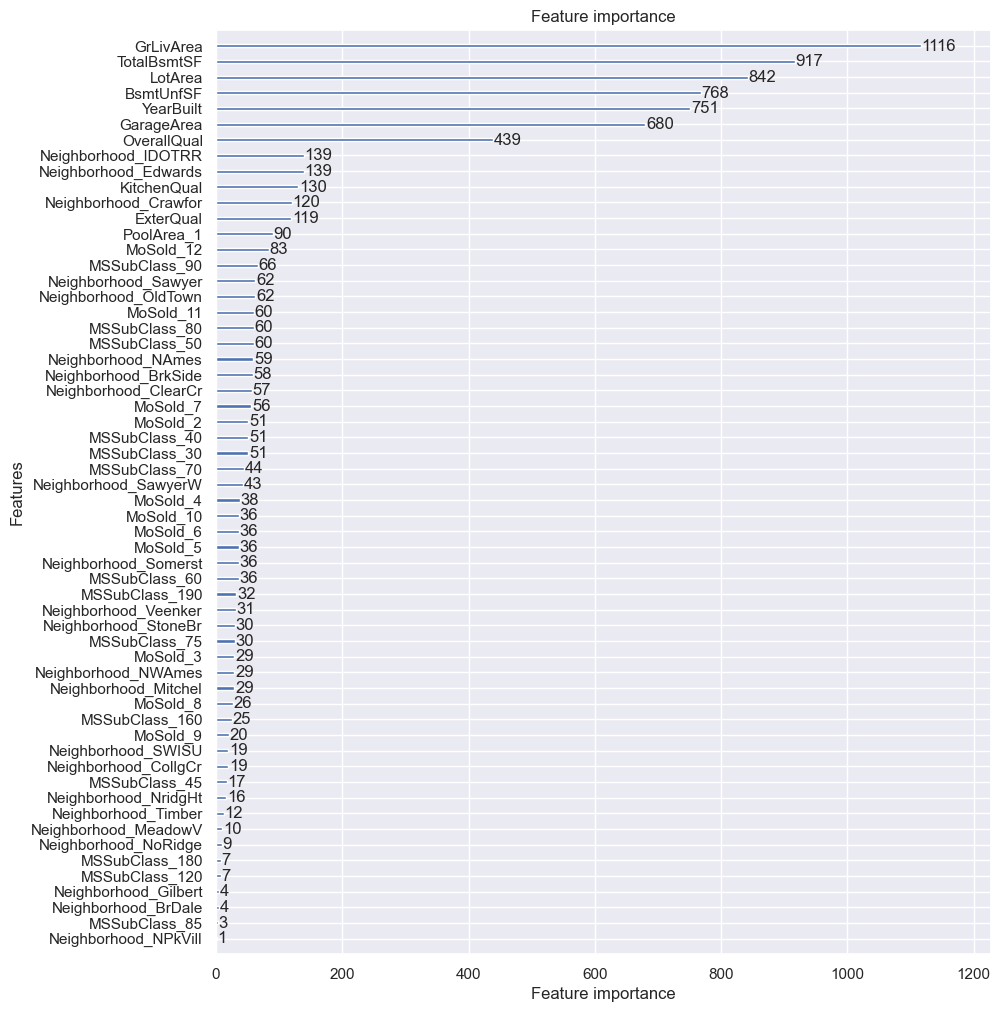

In [99]:
# feature importance
lgb.plot_importance(lgbm, figsize=(10,12));

**LightGBM with categorical features - old way**

In [100]:
# import label encoder
from sklearn.preprocessing import LabelEncoder

In [101]:
# check the data before one-hot encoding and scaling
print(df_proc.dtypes)
df_proc.head()

MSSubClass       object
LotArea           int64
Neighborhood     object
OverallQual       int64
YearBuilt         int64
PoolArea          int32
ExterQual         int64
BsmtUnfSF         int64
TotalBsmtSF       int64
GrLivArea       float64
KitchenQual       int64
GarageArea        int64
MoSold           object
SalePrice       float64
dtype: object


,MSSubClass,LotArea,Neighborhood,OverallQual,YearBuilt,PoolArea,ExterQual,BsmtUnfSF,TotalBsmtSF,GrLivArea,KitchenQual,GarageArea,MoSold,SalePrice
Id,,,,,,,,,,,,,,
1,60,8450,CollgCr,7,131,0,3,150,856,7.444833,3,548,2,12.247699
2,20,9600,Veenker,6,104,0,2,284,1262,7.141245,2,460,5,12.109016
3,60,11250,CollgCr,7,129,0,3,434,920,7.488294,3,608,9,12.317171
4,70,9550,Crawfor,7,43,0,2,540,756,7.448916,3,642,2,11.849405
5,60,14260,NoRidge,8,128,0,3,490,1145,7.695758,3,836,12,12.429220


In [102]:
# prepare dataset without one-hot encoding
df_no1hot_old = df_proc.copy()

# scale numerical features
df_no1hot_old[num_cols] = scaler.transform(df_proc[num_cols])

# encode categorical features
LEs = []
for col in cat_cols:
    LE = LabelEncoder().fit(df_no1hot_old[col])
    df_no1hot_old[col] = LE.transform(df_no1hot_old[col])
    LEs.append(LE)

# split the data
X_train_no1hot_old, X_test_no1hot_old, y_train_no1hot_old, y_test_no1hot_old = train_test_split(
    df_no1hot_old.drop(columns='SalePrice'), df_no1hot_old['SalePrice'], test_size=0.2, random_state=123
)

# check if the split is the same as before - check labels
print((y_train==y_train_no1hot_old).sum())
print((y_test==y_test_no1hot_old).sum())

# check the data
X_train_no1hot_old.head()

1168
292


,MSSubClass,LotArea,Neighborhood,OverallQual,YearBuilt,PoolArea,ExterQual,BsmtUnfSF,TotalBsmtSF,GrLivArea,KitchenQual,GarageArea,MoSold
Id,,,,,,,,,,,,,
319,5,0.104125,15,0.5,0.434783,0,1.0,-0.200855,0.707463,1.306796,1.0,0.728778,3
581,0,1.261487,12,0.0,-0.282609,0,0.0,-0.250427,0.303483,-0.053416,1.0,0.380952,5
962,5,0.678977,14,0.0,0.086957,0,0.0,-0.074359,0.673632,1.487781,0.0,0.575569,6
79,10,0.321023,19,-1.0,-0.108696,0,0.0,2.205983,1.545274,0.416532,0.0,-1.987578,3
6,4,1.145380,11,-0.5,0.434783,0,0.0,-0.706838,-0.389055,-0.159419,0.0,0.000000,9


In [103]:
# create dataset for lightgbm
lgb_train_cat_old = lgb.Dataset(X_train_no1hot_old, y_train_no1hot_old, free_raw_data=False, categorical_feature=cat_cols)
lgb_val_cat_old = lgb.Dataset(X_test_no1hot_old, y_test_no1hot_old, reference=lgb_train, free_raw_data=False, categorical_feature=cat_cols)

In [104]:
%%time
# train the model
lgbm_cat = lgb.train(
    params,
    lgb_train_cat_old,
    num_boost_round=2000,
    valid_sets=lgb_val_cat_old,
    categorical_feature=cat_cols
)

# evaluate the model
y_lgbm_cat_old = lgbm_cat.predict(X_test_no1hot_old)
error_lgbm_cat_old = root_mean_squared_error(y_test_no1hot_old, y_lgbm_cat_old)
print('RMSE of LGBM with categorical features (old way): {:6f}'.format(error_lgbm_cat_old))

RMSE of LGBM with categorical features (old way): 0.121409
CPU times: total: 4.36 s
Wall time: 381 ms


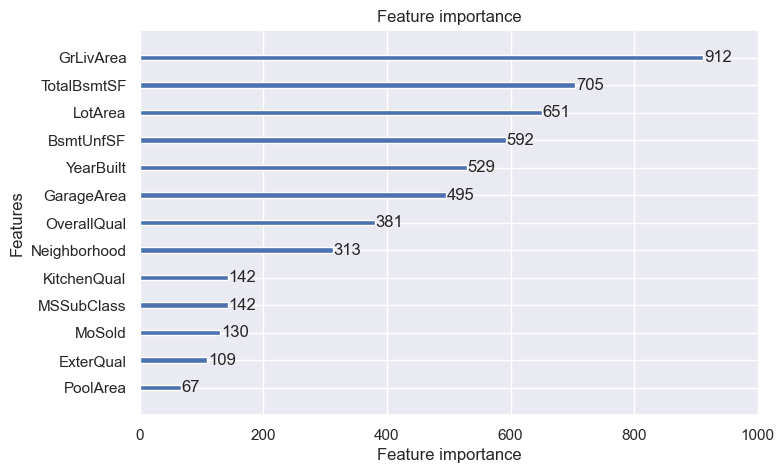

In [105]:
# feature importance
lgb.plot_importance(lgbm_cat, figsize=(8,5));

**LightGBM with categorical features - new way** \
https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.Dataset.html

In [106]:
# check the data
print(df_proc.dtypes)
df_proc.head()

MSSubClass       object
LotArea           int64
Neighborhood     object
OverallQual       int64
YearBuilt         int64
PoolArea          int32
ExterQual         int64
BsmtUnfSF         int64
TotalBsmtSF       int64
GrLivArea       float64
KitchenQual       int64
GarageArea        int64
MoSold           object
SalePrice       float64
dtype: object


,MSSubClass,LotArea,Neighborhood,OverallQual,YearBuilt,PoolArea,ExterQual,BsmtUnfSF,TotalBsmtSF,GrLivArea,KitchenQual,GarageArea,MoSold,SalePrice
Id,,,,,,,,,,,,,,
1,60,8450,CollgCr,7,131,0,3,150,856,7.444833,3,548,2,12.247699
2,20,9600,Veenker,6,104,0,2,284,1262,7.141245,2,460,5,12.109016
3,60,11250,CollgCr,7,129,0,3,434,920,7.488294,3,608,9,12.317171
4,70,9550,Crawfor,7,43,0,2,540,756,7.448916,3,642,2,11.849405
5,60,14260,NoRidge,8,128,0,3,490,1145,7.695758,3,836,12,12.429220


In [107]:
# prepare data
df_no1hot = df_proc.copy()

# scale numerical features
df_no1hot[num_cols] = scaler.transform(df_proc[num_cols])

# change dtypes of categorical features into 'category'
df_no1hot[cat_cols] = df_no1hot[cat_cols].astype('category')

# split the data
X_train_no1hot, X_test_no1hot, y_train_no1hot, y_test_no1hot = train_test_split(
    df_no1hot.drop(columns='SalePrice'), df_no1hot['SalePrice'], test_size=0.2, random_state=123
)

# check if the split is the same as before - check labels
print((y_train==y_train_no1hot).sum())
print((y_test==y_test_no1hot).sum())

1168
292


In [108]:
# check the newly prepared data
print(X_train_no1hot.dtypes)
X_train_no1hot.head()

MSSubClass      category
LotArea          float64
Neighborhood    category
OverallQual      float64
YearBuilt        float64
PoolArea        category
ExterQual        float64
BsmtUnfSF        float64
TotalBsmtSF      float64
GrLivArea        float64
KitchenQual      float64
GarageArea       float64
MoSold          category
dtype: object


,MSSubClass,LotArea,Neighborhood,OverallQual,YearBuilt,PoolArea,ExterQual,BsmtUnfSF,TotalBsmtSF,GrLivArea,KitchenQual,GarageArea,MoSold
Id,,,,,,,,,,,,,
319,60,0.104125,NoRidge,0.5,0.434783,0,1.0,-0.200855,0.707463,1.306796,1.0,0.728778,4
581,20,1.261487,NAmes,0.0,-0.282609,0,0.0,-0.250427,0.303483,-0.053416,1.0,0.380952,6
962,60,0.678977,NWAmes,0.0,0.086957,0,0.0,-0.074359,0.673632,1.487781,0.0,0.575569,7
79,90,0.321023,Sawyer,-1.0,-0.108696,0,0.0,2.205983,1.545274,0.416532,0.0,-1.987578,4
6,50,1.145380,Mitchel,-0.5,0.434783,0,0.0,-0.706838,-0.389055,-0.159419,0.0,0.000000,10


In [109]:
# create dataset for lightgbm
lgb_train_cat = lgb.Dataset(X_train_no1hot, y_train_no1hot, free_raw_data=False)
lgb_val_cat = lgb.Dataset(X_test_no1hot, y_test_no1hot, reference=lgb_train, free_raw_data=False)

In [110]:
%%time
# train the model
lgbm_cat = lgb.train(
    params,
    lgb_train_cat,
    num_boost_round=2000,
    valid_sets=lgb_val_cat,
)

# evaluate the model
y_lgbm_cat = lgbm_cat.predict(X_test_no1hot)
error_lgbm_cat = root_mean_squared_error(y_test_no1hot, y_lgbm_cat)
print('RMSE of LGBM with categorical features: {:6f}'.format(error_lgbm_cat))

RMSE of LGBM with categorical features: 0.121409
CPU times: total: 4.66 s
Wall time: 393 ms


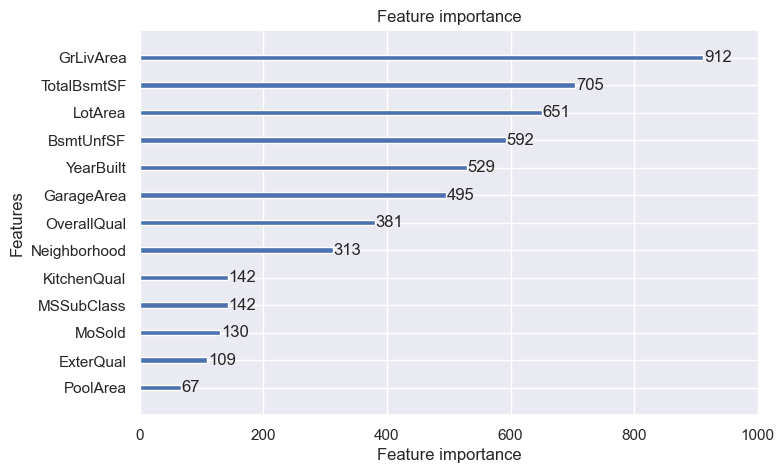

In [111]:
lgb.plot_importance(lgbm_cat, figsize=(8,5));

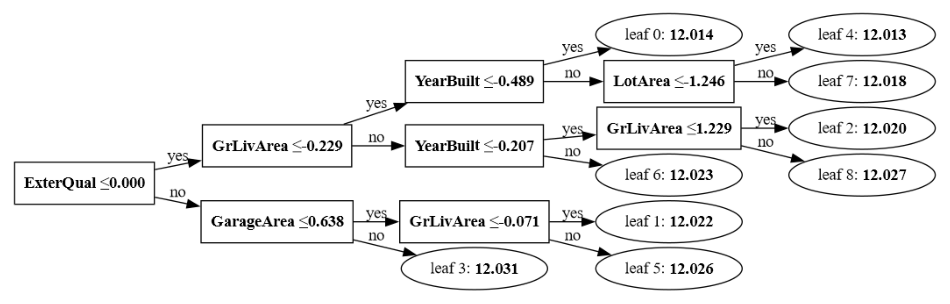

In [112]:
# plotting a tree
lgb.plot_tree(lgbm_cat, tree_index=0, figsize=(12,10));

In [113]:
# save the model to disk
filename = '../models/LGBM_with_categorical.pkl'
pickle.dump(lgbm_cat, open(filename, 'wb'))

### CatBoost
CatBoost documentation: https://catboost.ai/en/docs/

In [114]:
from catboost import Pool, CatBoostRegressor

In [115]:
# create dataset for catboost
train_pool = Pool(X_train_no1hot, 
                  y_train_no1hot, 
                  cat_features=cat_cols)
test_pool = Pool(X_test_no1hot,
                 y_test_no1hot,
                 cat_features=cat_cols)

In [116]:
%%time
# define the model and train - default hyperparameters
CBR_default = CatBoostRegressor(random_state=123, verbose=0)
CBR_default.fit(train_pool)

# evaluate the model
y_CBR_default = CBR_default.predict(X_test_no1hot)
error_CBR_default = root_mean_squared_error(y_test_no1hot, y_CBR_default)
print('RMSE of CatBoost with default hyperparameters: {:6f}'.format(error_CBR_default))

RMSE of CatBoost with default hyperparameters: 0.128310
CPU times: total: 48.9 s
Wall time: 19.9 s


In [117]:
%%time
# define the model and train - hyperparameters as GBR
CBR_asGBR = CatBoostRegressor(
    objective='RMSE',
    learning_rate=0.025,
    n_estimators=1200,
    #min_samples_split=2,
    #min_samples_leaf=1,
    max_depth=3,
    subsample=0.5,
    colsample_bylevel=0.6,
    random_state=123,
    verbose=0
)
CBR_asGBR.fit(train_pool)

# evaluate the model
y_CBR_asGBR = CBR_asGBR.predict(X_test_no1hot)
error_CBR_asGBR = root_mean_squared_error(y_test_no1hot, y_CBR_asGBR)
print('RMSE of CatBoost with GBR hyperparameters: {:6f}'.format(error_CBR_asGBR))

RMSE of CatBoost with GBR hyperparameters: 0.125941
CPU times: total: 27.3 s
Wall time: 13 s


In [118]:
%%time
# define the model and train - hyperparameters as XGB
CBR_asXGB = CatBoostRegressor(
    objective='RMSE',
    learning_rate=0.025,
    n_estimators=1200,
    #min_samples_split=2,
    #min_samples_leaf=1,
    max_depth=3,
    subsample=0.5,
    colsample_bylevel=0.6,
    reg_lambda=0,
    random_state=123,
    verbose=0
)
CBR_asXGB.fit(train_pool)

# evaluate the model
y_CBR_asXGB = CBR_asXGB.predict(X_test_no1hot)
error_CBR_asXGB = root_mean_squared_error(y_test_no1hot, y_CBR_asXGB)
print('RMSE of CatBoost with XGBoost hyperparameters: {:6f}'.format(error_CBR_asXGB))

RMSE of CatBoost with XGBoost hyperparameters: 0.127601
CPU times: total: 24.3 s
Wall time: 9.98 s


In [119]:
%%time
# define the model and train - hyperparameters as LightGBM
CBR_asLight = CatBoostRegressor(
    objective='RMSE',
    eval_metric='RMSE',
    iterations=2000,
    learning_rate=0.015,
    thread_count=12,
    min_child_samples=1,
    #num_leaves=9,
    max_depth=5,
    subsample=0.5,
    colsample_bylevel=0.6,
    reg_lambda=0,
    early_stopping_rounds=200,
    random_state=123,
    verbose=0
)
CBR_asLight.fit(train_pool, eval_set=test_pool)

# evaluate the model
y_CBR_asLight = CBR_asLight.predict(X_test_no1hot)
error_CBR_asLight = root_mean_squared_error(y_test_no1hot, y_CBR_asLight)
print('RMSE of CatBoost with LightGBM hyperparameters: {:6f}'.format(error_CBR_asLight))

RMSE of CatBoost with LightGBM hyperparameters: 0.126108
CPU times: total: 1min 1s
Wall time: 22.8 s


In [120]:
# save the models to disk
filename = '../models/CatBoost_default.pkl'
pickle.dump(CBR_default, open(filename, 'wb'))
 
filename = '../models/CatBoost_asGBR.pkl'
pickle.dump(CBR_asGBR, open(filename, 'wb'))

filename = '../models/CatBoost_asXGB.pkl'
pickle.dump(CBR_asXGB, open(filename, 'wb'))

filename = '../models/CatBoost_asLight.pkl'
pickle.dump(CBR_asLight, open(filename, 'wb'))

**CatBoost plots**

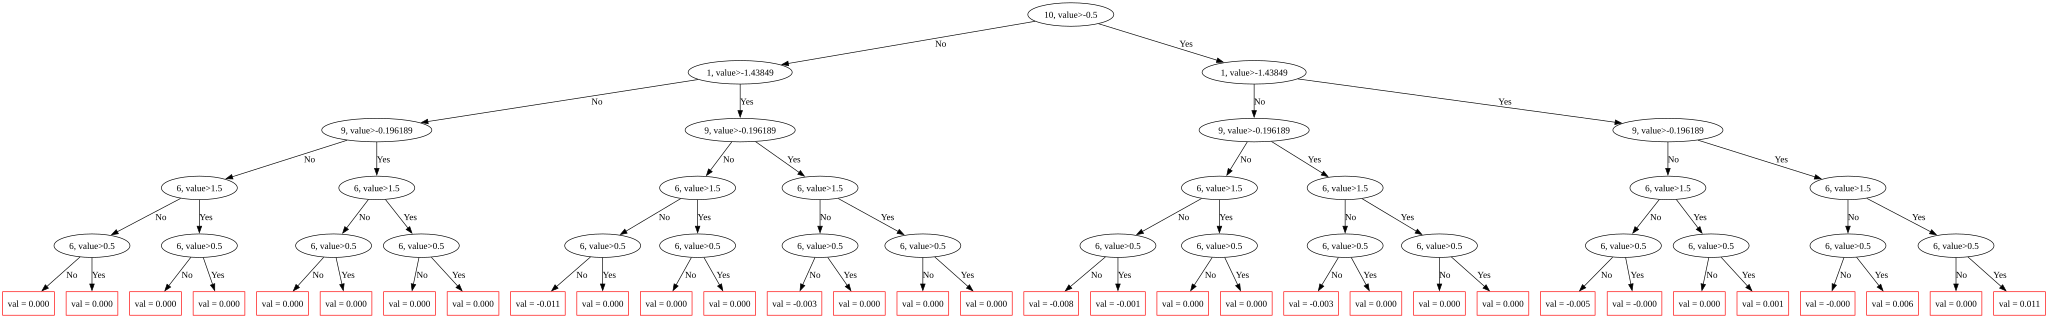

In [121]:
# plotting a tree
CBR_asLight.plot_tree(0)

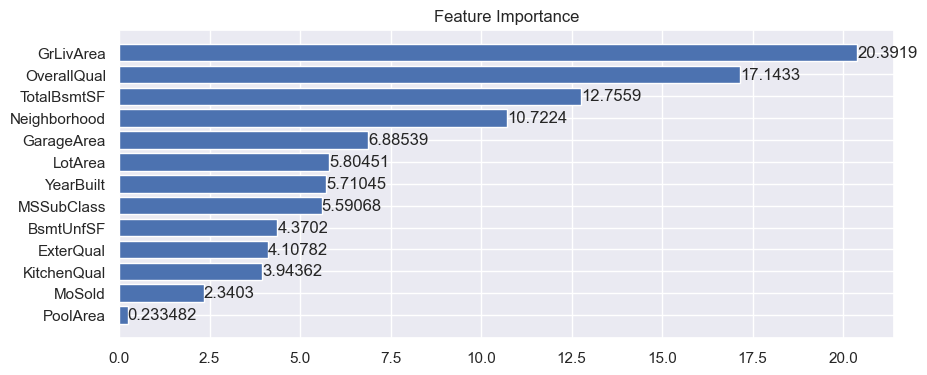

In [122]:
# plotting feature importance
feature_importance = CBR_asLight.feature_importances_
sorted_idx = np.argsort(feature_importance)
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
ax.bar_label(bars)
plt.yticks(range(len(sorted_idx)), np.array(X_test_no1hot.columns)[sorted_idx])
plt.title('Feature Importance');

# All done!

### Bonus: ensemble of ensemble

In [123]:
y_master1 = (y_blend + y_stack + y_GBR_tuned + y_XGB_tuned + y_lgbm_cat)/5
error_master1 = root_mean_squared_error(y_test, y_master1)
print('Ensemble of ensemble (1) RMSE: {:6f}'.format(error_master1))

Ensemble of ensemble (1) RMSE: 0.119165


In [124]:
y_master2 = (y_GBR_tuned + y_XGB_tuned + y_lgbm_cat + y_CBR_asGBR)/4
error_master2 = root_mean_squared_error(y_test, y_master2)
print('Ensemble of ensemble (2) RMSE: {:6f}'.format(error_master2))

Ensemble of ensemble (2) RMSE: 0.120746


In [125]:
y_master3 = (y_blend + y_stack + y_GBR_tuned + y_XGB_tuned + y_lgbm_cat + y_CBR_asGBR)/6
error_master3 = root_mean_squared_error(y_test, y_master3)
print('Ensemble of ensemble (3) RMSE: {:6f}'.format(error_master3))

Ensemble of ensemble (3) RMSE: 0.119655


In [128]:
%%time
# stacking the mighty 4 with Ridge
estimators = [
    ('GBR', GradientBoostingRegressor(
                learning_rate=0.025,
                n_estimators=1200,
                min_samples_split=2,
                min_samples_leaf=1,
                max_depth=3,
                subsample=0.5,
                max_features=0.6,
                random_state=123
    )),
    ('XGB', xgb.XGBRegressor(
                learning_rate=0.025,
                n_estimators=1200,
                #min_samples_split=2,
                #min_samples_leaf=1,
                max_depth=3,
                subsample=0.5,
                colsample_bytree=0.6,
                reg_lambda=0,
                reg_alpha=0,
                random_state=123
    )),
    ('LGBM', lgb.LGBMRegressor(
                learning_rate=0.015,
                n_estimators=1200,
                min_child_samples=1,
                num_leaves=9,
                max_depth=5,
                subsample=0.5,
                subsample_freq=1,
                colsample_bytree=0.6,
                random_state=123,
                verbose=-1
    )),
    ('CBR', CatBoostRegressor(
                objective='RMSE',
                learning_rate=0.025,
                n_estimators=1200,
                #min_samples_split=2,
                #min_samples_leaf=1,
                max_depth=3,
                subsample=0.5,
                colsample_bylevel=0.6,
                random_state=123,
                verbose=0
    ))
]
master_stack = StackingRegressor(estimators, final_estimator=Ridge(solver='svd', alpha=10), cv=4)
master_stack.fit(X_train, y_train)
y_master_stack = master_stack.predict(X_test)
error_master_stack = root_mean_squared_error(y_test, y_master_stack)
print('Master stacking RMSE with Ridge: {:6f}'.format(error_master_stack))

Master stacking RMSE with Ridge: 0.122133
CPU times: total: 1min 49s
Wall time: 18.6 s


In [129]:
%%time
# stacking the mighty 4 with Lasso
master_stack = StackingRegressor(estimators, final_estimator=Lasso(alpha=0.1), cv=4)
master_stack.fit(X_train, y_train)
y_master_stack = master_stack.predict(X_test)
error_master_stack = root_mean_squared_error(y_test, y_master_stack)
print('Master stacking RMSE with Lasso: {:6f}'.format(error_master_stack))

Master stacking RMSE with Lasso: 0.286462
CPU times: total: 1min 49s
Wall time: 18.2 s


_University of Zagreb Faculty of Electrical Engineering and Computing_  
_Laboratory for Renewable Energy Systems_  

_Course: AI bootcamp - basic_  
_Notebook: 6_Ensemble_Learning_House_Prices_  
_Instructors: [Filip Rukavina](mailto:filip.rukavina@fer.hr)_  
_Intended user: XY_  
_Date: 1st January 1991_  

_Website: [www.lares.fer.hr](https://www.lares.fer.hr/)_  
_Contact: [filip.rukavina@fer.hr](mailto:filip.rukavina@fer.hr)_